In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as XGB

In [2]:
data = pd.read_csv("loan_approval_data.csv")

In [3]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
data.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [6]:
#from info we know there should be 50 missing values in all columns, verifying it

data.isna().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [7]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [8]:
categorical_cols = data.select_dtypes(include = 'object').columns
numerical_cols = data.select_dtypes(include = 'float64').columns

In [9]:
num_imp = SimpleImputer(strategy = 'mean')

data[numerical_cols] = num_imp.fit_transform(data[numerical_cols])

In [10]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [11]:
categorical_imp = SimpleImputer(strategy = 'most_frequent')
data[categorical_cols] = categorical_imp.fit_transform(data[categorical_cols])

In [12]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [13]:
data.isna().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

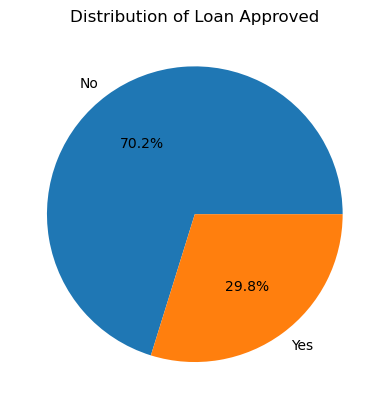

In [14]:
#Performing EDA to understand data better

class_count = data['Loan_Approved'].value_counts()
label = ['No', 'Yes']
plt.pie(
    class_count,
    labels = label,
    autopct = "%1.1f%%"
)
plt.title("Distribution of Loan Approved")
plt.show()

[Text(0, 0, '621'), Text(0, 0, '379')]

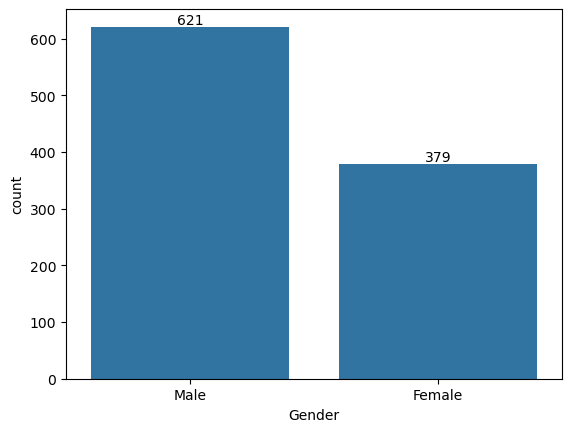

In [15]:
#Analyze categories

gender_cnt = data['Gender'].value_counts()
ax = sns.barplot(gender_cnt)

ax.bar_label(ax.containers[0])

In [16]:
data.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


In [17]:
emp_status = data['Employment_Status'].value_counts()

<Axes: xlabel='Employment_Status', ylabel='count'>

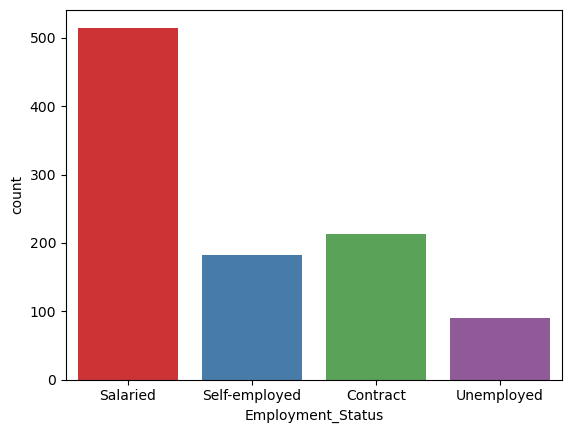

In [18]:
sns.countplot(
    data=data,
    x="Employment_Status",
    hue="Employment_Status",
    palette="Set1",
    legend=False
)

In [19]:
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


<Axes: xlabel='Credit_Score', ylabel='Applicant_Income'>

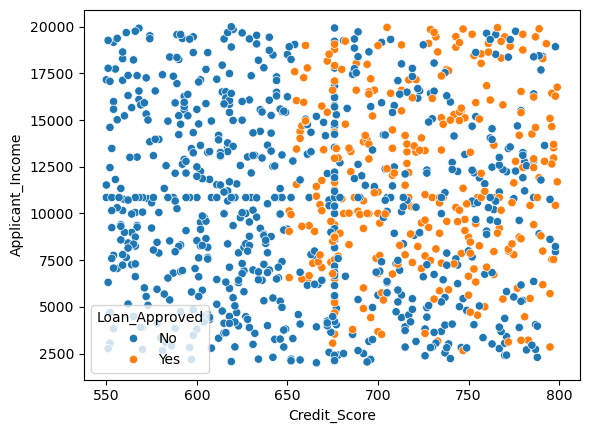

In [20]:
sns.scatterplot(
    data = data,
    y = 'Applicant_Income',
    x = 'Credit_Score',
    hue = 'Loan_Approved'
)

<Axes: xlabel='DTI_Ratio', ylabel='Credit_Score'>

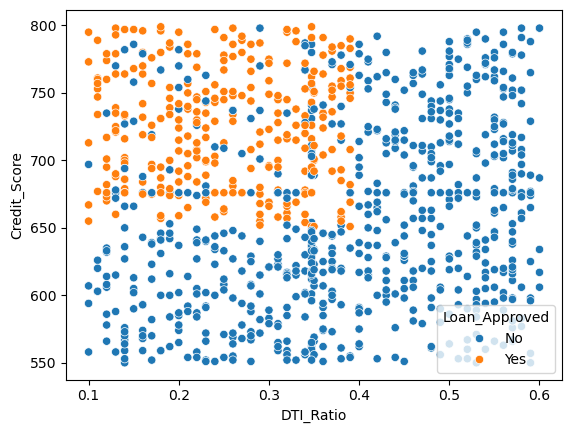

In [21]:
sns.scatterplot(
    data = data,
    x = 'DTI_Ratio',
    y = 'Credit_Score',
    hue = 'Loan_Approved'
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

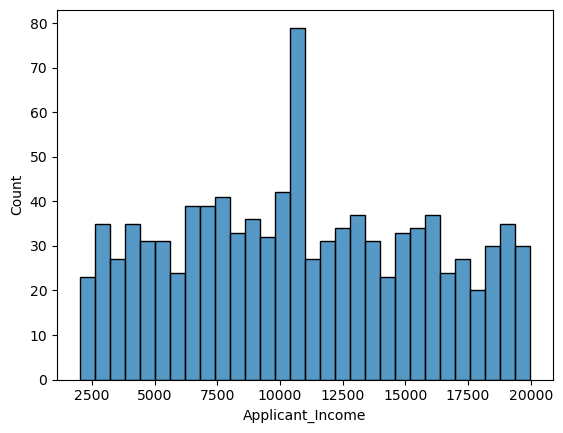

In [22]:
sns.histplot(
    data = data,
    x = 'Applicant_Income',
    bins = 30
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

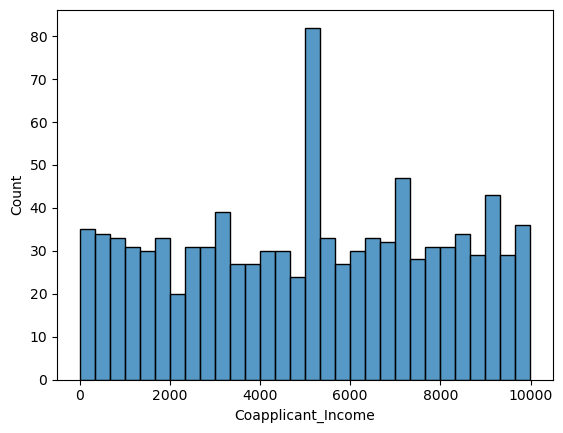

In [23]:
sns.histplot(
    data = data,
    x = 'Coapplicant_Income',
    bins = 30
)

In [24]:
data.head(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,6.0,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,7.0,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,8.0,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,9.0,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,10.0,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


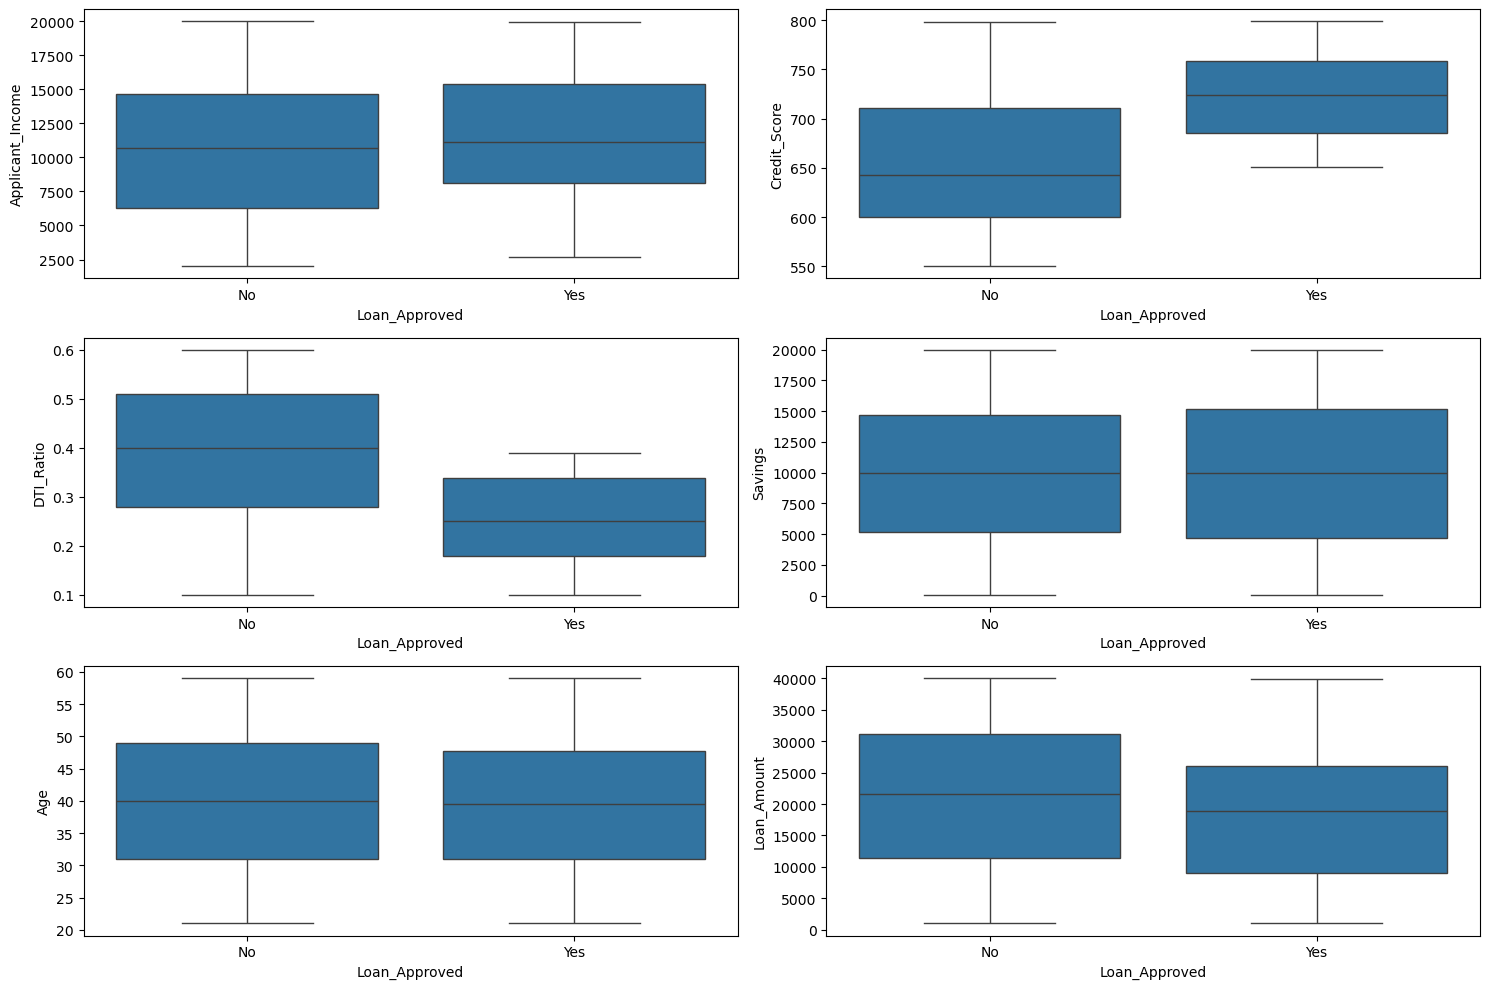

In [25]:
fig, ax = plt.subplots(3, 2, figsize = (15,10))

sns.boxplot(
    ax = ax[0,0],
    data = data,
    x = 'Loan_Approved',
    y = 'Applicant_Income'
)

sns.boxplot(
    ax = ax[0, 1],
    data = data,
    x = 'Loan_Approved',
    y = 'Credit_Score'
)

sns.boxplot(
    ax = ax[1, 0],
    data = data,
    x = 'Loan_Approved',
    y = 'DTI_Ratio'
)

sns.boxplot(
    ax = ax[1, 1],
    data = data,
    x = 'Loan_Approved',
    y = 'Savings'
)

sns.boxplot(
    ax = ax[2, 0],
    data = data,
    x = 'Loan_Approved',
    y = 'Age'
)

sns.boxplot(
    ax = ax[2, 1],
    data = data,
    x = 'Loan_Approved',
    y = 'Loan_Amount'
)

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

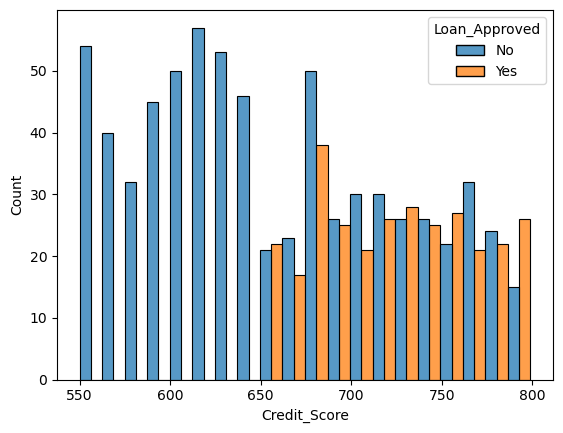

In [26]:
sns.histplot(
    data = data,
    x = 'Credit_Score',
    bins = 20,
    hue = 'Loan_Approved',
    multiple = 'dodge'
)

In [27]:
data = data.drop('Applicant_ID', axis = 1)
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [29]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [30]:
data['Loan_Approved'] = data['Loan_Approved'].map({
    "Yes" : 1,
    "No" : 0
})

data['Education_Level'] = data['Education_Level'].map({
    "Not Graduate" : 0,
    "Graduate" : 1,
})

In [31]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,0,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,1,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,1,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,1,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,1,Male,Private,1


In [32]:
one_hot_enc_cols = ['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area', 'Gender', 'Employer_Category']

encoder = OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore')
encoded = encoder.fit_transform(data[one_hot_enc_cols])

encoded_data = pd.DataFrame(encoded, columns = encoder.get_feature_names_out(one_hot_enc_cols), index = data.index)

In [33]:
encoded_data.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [34]:
dataProcessed = pd.concat([data.drop(one_hot_enc_cols, axis = 1), encoded_data], axis = 1)

In [35]:
dataProcessed.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

In [36]:
dataProcessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [37]:
nums_col = dataProcessed.select_dtypes(include = "number")
nums_col.corr()['Loan_Approved'].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Education_Level                    0.052920
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

<Axes: >

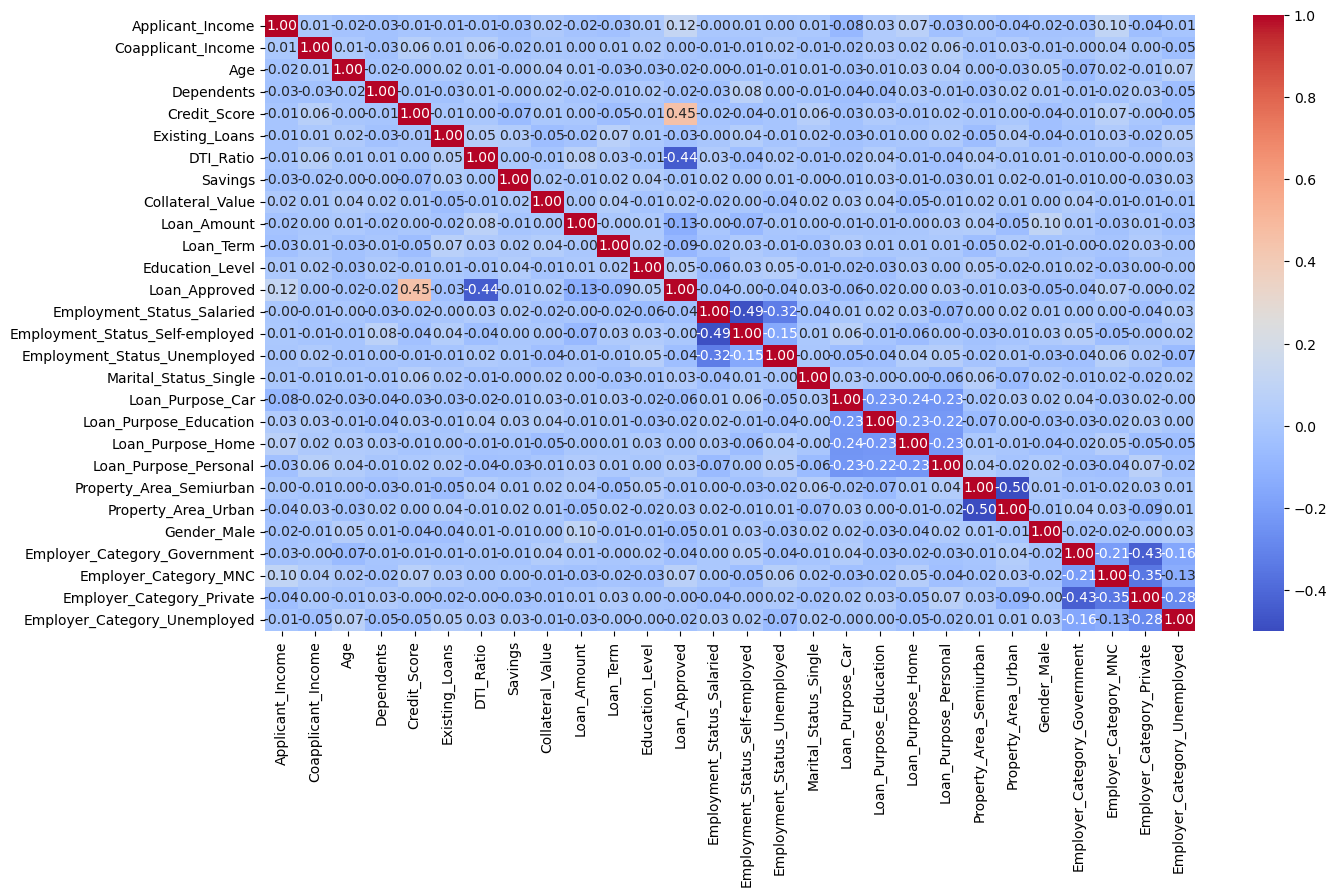

In [38]:
plt.figure(figsize = (15, 8))

sns.heatmap(
    nums_col.corr(),
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm'
)

In [39]:
X = dataProcessed.drop('Loan_Approved', axis = 1)
y = dataProcessed['Loan_Approved']

In [40]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
logReg = LogisticRegression(
    # max_iter = 10000,
    # solver = 'liblinear'
)
logReg.fit(X_train_scaled, y_train)

y_pred = logReg.predict(X_test_scaled)

#Evaluation

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 78.33333333333333 %
Recall : 77.04918032786885 %
F1 : 77.68595041322314 %
Accuracy : 86.5 %
Confusion Matrix : [[126  13]
 [ 14  47]] %


In [44]:
knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 62.745098039215684 %
Recall : 52.459016393442624 %
F1 : 57.14285714285714 %
Accuracy : 76.0 %
Confusion Matrix : [[120  19]
 [ 29  32]] %


In [45]:
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 80.35714285714286 %
Recall : 73.77049180327869 %
F1 : 76.92307692307693 %
Accuracy : 86.5 %
Confusion Matrix : [[128  11]
 [ 16  45]] %


# Feature Engineering

In [46]:
dataProcessed['DTI_Ratio_sq'] = dataProcessed['DTI_Ratio'] ** 2
dataProcessed['Credit_Score_sq'] = dataProcessed['Credit_Score'] ** 2

X = dataProcessed.drop(columns = ["DTI_Ratio", "Credit_Score", "Loan_Approved"])
y = dataProcessed["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train, y_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
logReg = LogisticRegression(
    # max_iter = 10000,
    # solver = 'liblinear'
)
logReg.fit(X_train_scaled, y_train)

y_pred = logReg.predict(X_test_scaled)

#Evaluation

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 79.03225806451613 %
Recall : 80.32786885245902 %
F1 : 79.67479674796748 %
Accuracy : 87.5 %
Confusion Matrix : [[126  13]
 [ 12  49]] %


In [48]:
knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 62.0 %
Recall : 50.81967213114754 %
F1 : 55.85585585585585 %
Accuracy : 75.5 %
Confusion Matrix : [[120  19]
 [ 30  31]] %


In [49]:
gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)
y_pred = gnb.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 78.33333333333333 %
Recall : 77.04918032786885 %
F1 : 77.68595041322314 %
Accuracy : 86.5 %
Confusion Matrix : [[126  13]
 [ 14  47]] %


In [50]:
xgb = XGB.XGBClassifier()

xgb.fit(X_train_scaled, y_train),
y_pred = xgb.predict(X_test_scaled)

print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 84.84848484848484 %
Recall : 91.80327868852459 %
F1 : 88.18897637795276 %
Accuracy : 92.5 %
Confusion Matrix : [[129  10]
 [  5  56]] %


In [72]:
pipeline = Pipeline(
    [
        ('model', LogisticRegression())
    ]
)

params = [
    {
        "model" : [LogisticRegression()],
        "model__max_iter" : [2000, 4000, 8000],
        "model__C" : [0.1, 0.01, 0.2, 0.5, 1],
        "model__solver" : ['liblinear']
    },
    {
        "model" : [KNeighborsClassifier()],
        "model__n_neighbors" : [3, 5, 7, 9, 11],
    },
    {
        "model" : [GaussianNB()]
    },
    {
        "model" : [RandomForestClassifier()],
        "model__n_estimators" : [100, 200, 300],
        "model__max_depth" : [3, 5, 7, 9],
        "model__min_samples_split" : [5, 9, 11, 3]
    },
    {
        "model": [XGB.XGBClassifier()],
        "model__n_estimators": [100, 200, 300, 400],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
        "model__max_depth": [3, 6, 7, 9]
    }
    
]

grid = GridSearchCV(
    estimator = pipeline,
    param_grid = params,
    scoring = 'recall',
    cv = 5,
    verbose = 1
)

In [73]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 133 candidates, totalling 665 fits


,estimator,Pipeline(step...egression())])
,param_grid,"[{'model': [LogisticRegression()], 'model__C': [0.1, 0.01, ...], 'model__max_iter': [2000, 4000, ...], 'model__solver': ['liblinear']}, {'model': [KNeighborsClassifier()], 'model__n_neighbors': [3, 5, ...]}, ...]"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [74]:
y_pred = grid.predict(X_test_scaled)

In [75]:
print(f"Precision : {precision_score(y_test, y_pred) * 100} %")
print(f"Recall : {recall_score(y_test, y_pred) * 100} %")
print(f"F1 : {f1_score(y_test, y_pred) * 100} %")
print(f"Accuracy : {accuracy_score(y_test, y_pred) * 100} %")
print(f"Confusion Matrix : {confusion_matrix(y_test, y_pred)} %")

Precision : 84.28571428571429 %
Recall : 96.72131147540983 %
F1 : 90.07633587786259 %
Accuracy : 93.5 %
Confusion Matrix : [[128  11]
 [  2  59]] %


In [76]:
print(grid.best_score_)
print(grid.best_params_)

0.9576241134751772
{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...), 'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 400}
